<a href="https://colab.research.google.com/github/sathkumara-smna/258739K/blob/main/site_power_ML_cell_to_site.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
# ============================================================
# FULLY DATA-DRIVEN CELL-WISE ML MODEL
# PREDICT CELL POWER FIRST
# AGGREGATE PREDICTED CELL POWER AFTERWARD
# NO ENGINEERING EQUATIONS
# NO MANUAL POWER PARAMETERS
# OPTIMIZED / FASTER VERSION
# - 2G / 3G STATIC SITE FEATURES
# - FINAL OUTPUT = 75 x 96 x 7 = 50400 ROWS
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# LOAD EXCEL FILES FROM GITHUB
# ============================================================

site_db_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/Site%20Database%20from%20Sey.xlsx"
site_power_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power%20from%20Sey.xlsx"
traffic_4g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/4G%20Traffic.xlsx"
traffic_5g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/5G%20Traffic.xlsx"

# ============================================================
# READ EXCEL FILES
# ============================================================

site_db = pd.read_excel(site_db_url)
site_power = pd.read_excel(site_power_url)
traffic_4g = pd.read_excel(traffic_4g_url)
traffic_5g = pd.read_excel(traffic_5g_url)
site_db.head(2)

,#,Site_ID,Site Name,2G RRUs,3G RRUs,4G RRUs,5G AAUs,2G Boards,3G Boards,4G Boards,5G Boards,BBU 5900,BBU 3900,BBU 3910
0,1,101,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,2,102,AIRPORT_PRASLIN,2,4,4,0,1,1,1,0,0,1,0


In [77]:
# ============================================================
# CONVERT DATETIME
# ============================================================

site_power['datetime'] = pd.to_datetime(
    site_power['datetime']
)
traffic_4g['datetime'] = pd.to_datetime(
    traffic_4g['datetime']
)
traffic_5g['datetime'] = pd.to_datetime(
    traffic_5g['datetime']
)
site_power.head(2)

,Site_ID,trigger_ID,date,datetime,site_power
0,101,1,2026-03-01,2026-03-01 00:00:00,6517.6299
1,101,2,2026-03-01,2026-03-01 00:15:00,6533.5512


In [78]:
# ============================================================
# RENAME SITE DATABASE COLUMNS
# ============================================================

site_db.columns = [
    '#','Site_ID','Site_Name','RRU_2G','RRU_3G','RRU_4G','AAU_5G','Col_H',
    'Col_I','Boards_4G','Boards_5G','BBU5900','BBU3900','BBU3910'
]
site_db.head(2)

,#,Site_ID,Site_Name,RRU_2G,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,1,101,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,2,102,AIRPORT_PRASLIN,2,4,4,0,1,1,1,0,0,1,0


In [79]:
# ============================================================
# CREATE TIME FEATURES
# ============================================================

traffic_4g['hour'] = (
    traffic_4g['datetime'].dt.hour
)

traffic_5g['hour'] = (
    traffic_5g['datetime'].dt.hour
)
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0


In [80]:
# ============================================================
# CREATE TECHNOLOGY COLUMN
# ============================================================

traffic_4g['technology'] = '4G'
traffic_5g['technology'] = '5G'
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G


In [81]:
# ============================================================
# LTE CELL COUNTS
# ============================================================

lte_counts = (

    traffic_4g.groupby('Site_ID')['Cell_ID']
    .nunique()
    .reset_index()

)

lte_counts.rename(
    columns={'Cell_ID': 'lte_cell_count'},
    inplace=True
)
lte_counts.head(2)

,Site_ID,lte_cell_count
0,101,12
1,102,4


In [82]:
# ============================================================
# NR CELL COUNTS
# ============================================================

nr_counts = (

    traffic_5g.groupby('Site_ID')['Cell_ID']
    .nunique()
    .reset_index()

)

nr_counts.rename(
    columns={'Cell_ID': 'nr_cell_count'},
    inplace=True
)
nr_counts.head(2)

,Site_ID,nr_cell_count
0,101,3
1,103,3


In [83]:
# ============================================================
# MERGE COUNTS TO LTE
# ============================================================

traffic_4g = traffic_4g.merge(
    lte_counts,
    on='Site_ID',
    how='left'
)

traffic_4g = traffic_4g.merge(
    nr_counts,
    on='Site_ID',
    how='left'
)
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,nr_cell_count
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,3.0
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,3.0


In [84]:
# ============================================================
# MERGE COUNTS TO NR
# ============================================================

traffic_5g = traffic_5g.merge(
    lte_counts,
    on='Site_ID',
    how='left'
)

traffic_5g = traffic_5g.merge(
    nr_counts,
    on='Site_ID',
    how='left'
)
traffic_5g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,nr_cell_count
0,101,1011,1,1,2026-03-01,2026-03-01 00:00:00,61.20,0,5G,12,3
1,101,1011,1,2,2026-03-01,2026-03-01 00:15:00,67.31,0,5G,12,3


In [85]:
# ============================================================
# MERGE SITE DATABASE
# ============================================================

traffic_4g = traffic_4g.merge(
    site_db,
    on='Site_ID',
    how='left'
)

traffic_5g = traffic_5g.merge(
    site_db,
    on='Site_ID',
    how='left'
)
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,7,12,3,1,2,2,1,1,1,1
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,7,12,3,1,2,2,1,1,1,1


In [86]:
# ============================================================
# AGGREGATE TOTAL TRAFFIC
# ============================================================

lte_total = (

    traffic_4g.groupby(
        ['Site_ID', 'trigger_ID', 'date', 'datetime'],
        as_index=False
    )['traffic_load_mbps']

    .sum()

)

lte_total.rename(
    columns={'traffic_load_mbps': 'total_4g_traffic'},
    inplace=True
)

nr_total = (

    traffic_5g.groupby(
        ['Site_ID', 'trigger_ID', 'date', 'datetime'],
        as_index=False
    )['traffic_load_mbps']

    .sum()

)

nr_total.rename(
    columns={'traffic_load_mbps': 'total_5g_traffic'},
    inplace=True
)
lte_total.head(2)

,Site_ID,trigger_ID,date,datetime,total_4g_traffic
0,101,1,2026-03-01,2026-03-01,150.81
1,101,1,2026-03-02,2026-03-02,154.18


In [87]:
# ============================================================
# MERGE TOTAL TRAFFIC TO LTE
# ============================================================
traffic_4g = traffic_4g.merge(

    lte_total,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)

traffic_4g = traffic_4g.merge(

    nr_total,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,3,1,2,2,1,1,1,1,150.81,172.34
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,3,1,2,2,1,1,1,1,155.48,188.49


In [88]:
# ============================================================
# MERGE TOTAL TRAFFIC TO NR
# ============================================================

traffic_5g = traffic_5g.merge(

    lte_total,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)

traffic_5g = traffic_5g.merge(

    nr_total,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)
traffic_5g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic
0,101,1011,1,1,2026-03-01,2026-03-01 00:00:00,61.20,0,5G,12,...,3,1,2,2,1,1,1,1,150.81,172.34
1,101,1011,1,2,2026-03-01,2026-03-01 00:15:00,67.31,0,5G,12,...,3,1,2,2,1,1,1,1,155.48,188.49


In [89]:
# ============================================================
# MERGE ACTUAL SITE POWER
# ============================================================

traffic_4g = traffic_4g.merge(

    site_power,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)

traffic_5g = traffic_5g.merge(

    site_power,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic,site_power
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,1,2,2,1,1,1,1,150.81,172.34,6517.6299
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,1,2,2,1,1,1,1,155.48,188.49,6533.5512


In [90]:
# ============================================================
# FILL NULLS
# ============================================================

traffic_4g.fillna(0, inplace=True)
traffic_5g.fillna(0, inplace=True)
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic,site_power
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,1,2,2,1,1,1,1,150.81,172.34,6517.6299
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,1,2,2,1,1,1,1,155.48,188.49,6533.5512


In [91]:
# ============================================================
# ESTIMATE CELL TARGET POWER
# ============================================================

traffic_4g['cell_target_power'] = (
    traffic_4g['site_power'] * (traffic_4g['traffic_load_mbps']/(
            traffic_4g['total_4g_traffic']+traffic_4g['total_5g_traffic']+1)))

traffic_5g['cell_target_power'] = (traffic_5g['site_power']*(traffic_5g['traffic_load_mbps']
        /(traffic_5g['total_4g_traffic']+traffic_5g['total_5g_traffic']+1)))
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic,site_power,cell_target_power
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,2,2,1,1,1,1,150.81,172.34,6517.6299,239.271312
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,2,2,1,1,1,1,155.48,188.49,6533.5512,227.841902


In [92]:
# ============================================================
# COMBINE LTE + NR DATA
# ============================================================

cell_df = pd.concat(
    [traffic_4g, traffic_5g],
    ignore_index=True
)
cell_df.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic,site_power,cell_target_power
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,2,2,1,1,1,1,150.81,172.34,6517.6299,239.271312
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,2,2,1,1,1,1,155.48,188.49,6533.5512,227.841902


In [93]:
# ============================================================
# FEATURES
# ============================================================
features = [

    'traffic_load_mbps',

    'hour',
    'trigger_ID',

    'lte_cell_count',
    'nr_cell_count',

    'RRU_2G',
    'RRU_3G',
    'RRU_4G',

    'AAU_5G',

    'Boards_4G',
    'Boards_5G',

    'BBU5900',
    'BBU3900',
    'BBU3910'

]

X = cell_df[features]
y = cell_df['cell_target_power']
print("Done")

Done


In [94]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42

)
print("Done")

Done


In [95]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

model = RandomForestRegressor(

    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1

)

model.fit(X_train, y_train)
print("Done")

Done


In [96]:
# ============================================================
# PREDICT CELL POWER
# ============================================================

cell_df['predicted_cell_power'] = (

    model.predict(
        cell_df[features]
    )

)
cell_df.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps,hour,technology,lte_cell_count,...,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910,total_4g_traffic,total_5g_traffic,site_power,cell_target_power,predicted_cell_power
0,101,10111,11,1,2026-03-01,2026-03-01 00:00:00,11.90,0,4G,12,...,2,1,1,1,1,150.81,172.34,6517.6299,239.271312,252.334136
1,101,10111,11,2,2026-03-01,2026-03-01 00:15:00,12.03,0,4G,12,...,2,1,1,1,1,155.48,188.49,6533.5512,227.841902,252.328689


In [97]:
# ============================================================
# AGGREGATE PREDICTED CELL POWER
# ============================================================

final_df = (

    cell_df.groupby(
        ['Site_ID', 'trigger_ID', 'date', 'datetime'],
        as_index=False
    )['predicted_cell_power']

    .sum()

)
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,predicted_cell_power
0,101,1,2026-03-01,2026-03-01,6681.584976
1,101,1,2026-03-02,2026-03-02,7858.343282


In [98]:
# ============================================================
# RENAME COLUMN
# ============================================================

final_df.rename(

    columns={
        'predicted_cell_power': 'predicted_site_power'
    },

    inplace=True

)
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,predicted_site_power
0,101,1,2026-03-01,2026-03-01,6681.584976
1,101,1,2026-03-02,2026-03-02,7858.343282


In [99]:
# ============================================================
# MERGE ACTUAL SITE POWER
# ============================================================

final_df = final_df.merge(

    site_power,

    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],

    how='left'

)
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,predicted_site_power,site_power
0,101,1,2026-03-01,2026-03-01,6681.584976,6517.6299
1,101,1,2026-03-02,2026-03-02,7858.343282,6467.9894


In [100]:
# ============================================================
# EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(

    final_df['site_power'],
    final_df['predicted_site_power']

)

rmse = np.sqrt(

    mean_squared_error(

        final_df['site_power'],
        final_df['predicted_site_power']

    )

)

mape = np.mean(

    np.abs(

        (

            final_df['site_power']
            -
            final_df['predicted_site_power']

        )

        /

        final_df['site_power']

    )

) * 100

r2 = r2_score(

    final_df['site_power'],
    final_df['predicted_site_power']

)
print("Done")

Done


In [101]:
# ============================================================
# PRINT RESULTS
# ============================================================

print('================================')
print('CELL-WISE ML PERFORMANCE')
print('================================')

print(f'MAE  : {round(mae, 2)}')
print(f'RMSE : {round(rmse, 2)}')
print(f'MAPE : {round(mape, 2)} %')
print(f'R2   : {round(r2, 4)}')


CELL-WISE ML PERFORMANCE
MAE  : 459.09
RMSE : 640.08
MAPE : 11.88 %
R2   : 0.9034


In [102]:
# ============================================================
# ERROR CALCULATION
# ============================================================

final_df['error'] = (

    final_df['site_power']
    -
    final_df['predicted_site_power']

)

final_df['error_percentage'] = (

    np.abs(final_df['error'])
    /
    final_df['site_power']

) * 100
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,predicted_site_power,site_power,error,error_percentage
0,101,1,2026-03-01,2026-03-01,6681.584976,6517.6299,-163.955076,2.515563
1,101,1,2026-03-02,2026-03-02,7858.343282,6467.9894,-1390.353882,21.495921


In [103]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    'Feature': features,
    'Importance': model.feature_importances_

})

importance_df = importance_df.sort_values(

    by='Importance',
    ascending=False

)

print('================================')
print('FEATURE IMPORTANCE')
print('================================')

print(importance_df)

FEATURE IMPORTANCE
              Feature  Importance
0   traffic_load_mbps    0.813499
2          trigger_ID    0.058654
4       nr_cell_count    0.022292
10          Boards_5G    0.021023
11            BBU5900    0.017961
8              AAU_5G    0.013409
5              RRU_2G    0.012382
7              RRU_4G    0.011781
1                hour    0.011604
3      lte_cell_count    0.009338
6              RRU_3G    0.005784
13            BBU3910    0.002123
9           Boards_4G    0.000149
12            BBU3900    0.000000


In [104]:
# ============================================================
# EXPORT RESULTS
# ============================================================

final_df.to_excel(

    'Fully_Data_Driven_Cell_Wise_Predictions.xlsx',
    index=False

)

print('================================')
print('OUTPUT FILE CREATED')
print('================================')

print('Fully_Data_Driven_Cell_Wise_Predictions.xlsx')

# ============================================================
# SAMPLE RESULTS
# ============================================================

print(final_df.head(20))

OUTPUT FILE CREATED
Fully_Data_Driven_Cell_Wise_Predictions.xlsx
    Site_ID  trigger_ID        date            datetime  predicted_site_power  \
0       101           1  2026-03-01 2026-03-01 00:00:00           6681.584976   
1       101           1  2026-03-02 2026-03-02 00:00:00           7858.343282   
2       101           1  2026-03-03 2026-03-03 00:00:00           5662.500703   
3       101           1  2026-03-04 2026-03-04 00:00:00           6101.706266   
4       101           1  2026-03-05 2026-03-05 00:00:00           4491.005685   
5       101           1  2026-03-06 2026-03-06 00:00:00           6564.618059   
6       101           1  2026-03-07 2026-03-07 00:00:00           5278.121663   
7       101           2  2026-03-01 2026-03-01 00:15:00           6818.817679   
8       101           2  2026-03-02 2026-03-02 00:15:00           7974.711810   
9       101           2  2026-03-03 2026-03-03 00:15:00           5730.643272   
10      101           2  2026-03-04 2026-03-

In [105]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ERROR PERCENTAGE
# ============================================================

final_df['error_percentage'] = (

    np.abs(

        final_df['site_power']
        -
        final_df['predicted_site_power']

    )

    /

    final_df['site_power']

) * 100
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,predicted_site_power,site_power,error,error_percentage
0,101,1,2026-03-01,2026-03-01,6681.584976,6517.6299,-163.955076,2.515563
1,101,1,2026-03-02,2026-03-02,7858.343282,6467.9894,-1390.353882,21.495921


In [106]:
# ============================================================
# CREATE ABSOLUTE ERROR COLUMN
# ============================================================

final_df['absolute_error'] = (

    abs(

        final_df['error']

    )

)

# ============================================================
# PICK MAXIMUM ABSOLUTE ERROR ROW PER SITE
# ============================================================

summary_df = (

    final_df.loc[

        final_df.groupby('Site_ID')['absolute_error'].idxmax()

    ]

)

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

summary_df = summary_df[

    [
        'Site_ID',
        'predicted_site_power',
        'site_power',
        'error',
        'error_percentage'
    ]

]

# ============================================================
# SORT BY SITE_ID
# ============================================================

summary_df = summary_df.sort_values(
    by='Site_ID'
)

# ============================================================
# RESET INDEX
# ============================================================

summary_df = summary_df.reset_index(drop=True)

# ============================================================
# EXPORT EXCEL
# ============================================================

summary_df.to_excel(

    "Fully_Data_Driven_Cell_Wise_Predictions_Summary.xlsx",

    index=False

)

# ============================================================
# SHOW FIRST ROWS
# ============================================================

summary_df.head()

,Site_ID,predicted_site_power,site_power,error,error_percentage
0,101,8401.149431,6193.3173,-2207.832131,35.648620
1,102,2832.926031,2098.3219,-734.604131,35.009125
2,103,9068.062251,5810.1980,-3257.864251,56.071484
3,104,2102.290221,1610.1498,-492.140421,30.564884
4,105,7040.377120,5083.0831,-1957.294020,38.506040


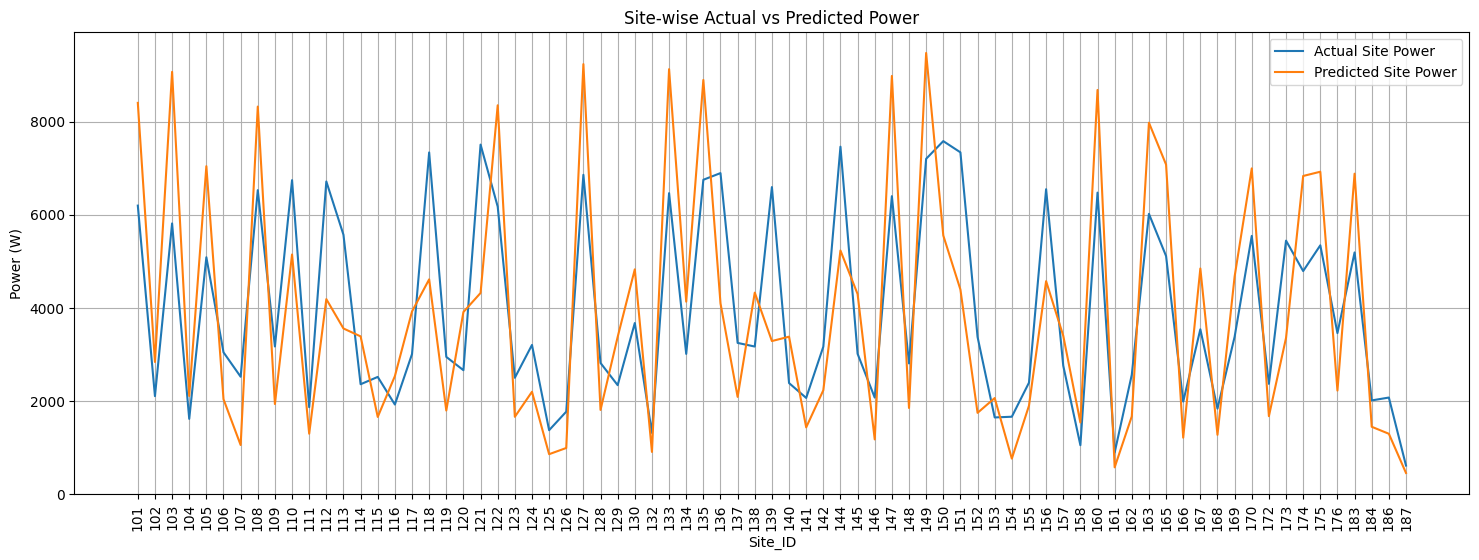

In [107]:
# ============================================================
# 1. ACTUAL VS PREDICTED POWER SITE-WISE
# ============================================================
plt.figure(figsize=(18,6))
plt.plot(summary_df['Site_ID'].astype(str),summary_df['site_power'],label='Actual Site Power')
plt.plot(    summary_df['Site_ID'].astype(str),summary_df['predicted_site_power'],label='Predicted Site Power')

plt.xlabel('Site_ID')
plt.ylabel('Power (W)')
plt.title('Site-wise Actual vs Predicted Power')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

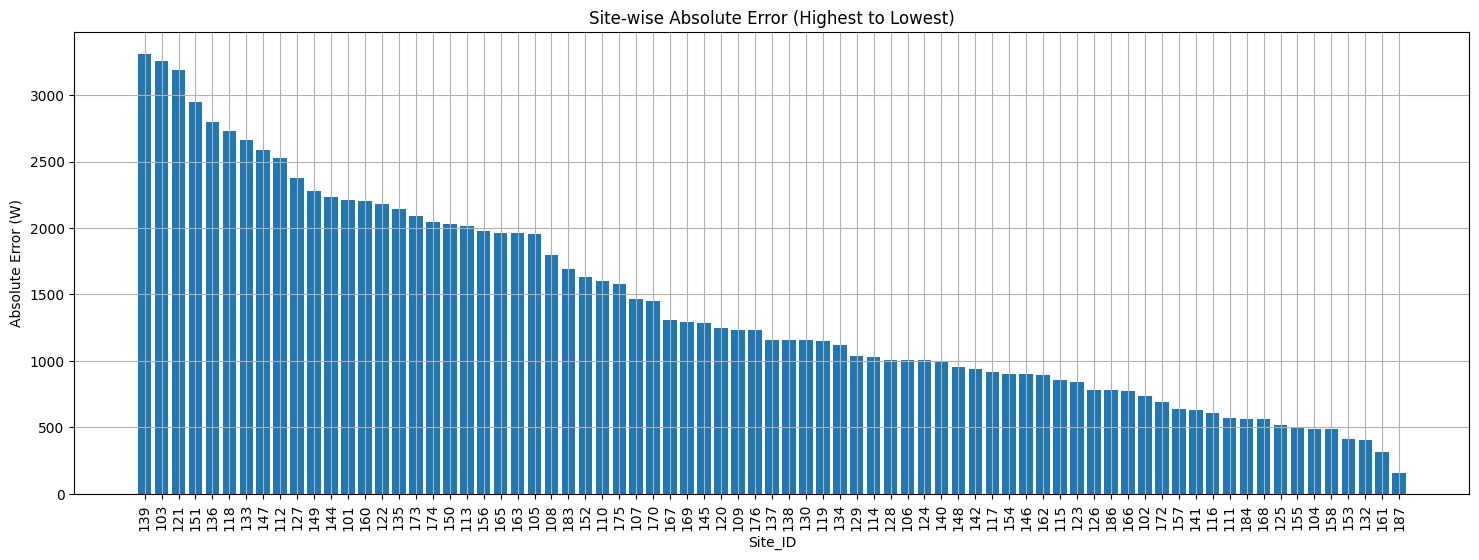

In [114]:
# ============================================================
# 2. ABSOLUTE ERROR SITE-WISE
# ============================================================

# ============================================================
# ABSOLUTE ERROR
# ============================================================

summary_df['absolute_error'] = (abs(summary_df['error']))

# ============================================================
# SORT FROM MAXIMUM TO MINIMUM
# ============================================================

summary_df_sorted = summary_df.sort_values(by='absolute_error',ascending=False)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(18,6))
plt.bar(summary_df_sorted['Site_ID'].astype(str),summary_df_sorted['absolute_error'])

plt.xlabel('Site_ID')
plt.ylabel('Absolute Error (W)')
plt.title('Site-wise Absolute Error (Highest to Lowest)')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

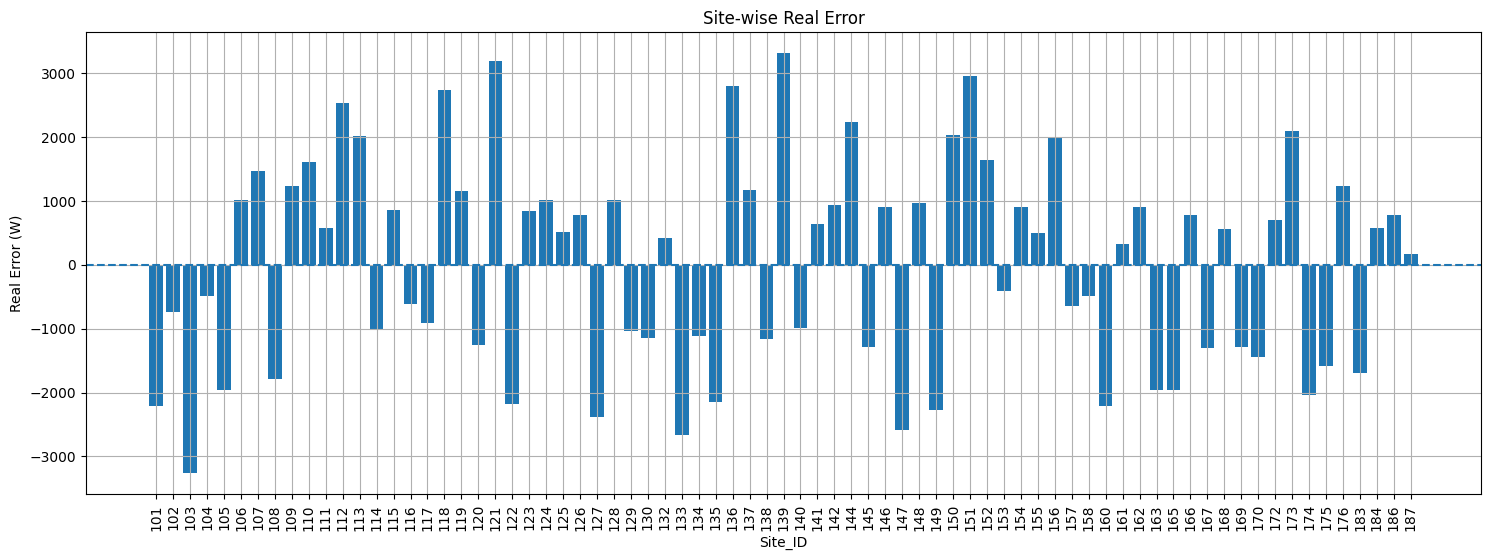

In [109]:
# ============================================================
# 3. REAL ERROR SITE-WISE
# ============================================================

plt.figure(figsize=(18,6))
plt.bar(summary_df['Site_ID'].astype(str),summary_df['error'])

# Zero reference line
plt.axhline(    y=0,    linestyle='--')

plt.xlabel('Site_ID')
plt.ylabel('Real Error (W)')
plt.title('Site-wise Real Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

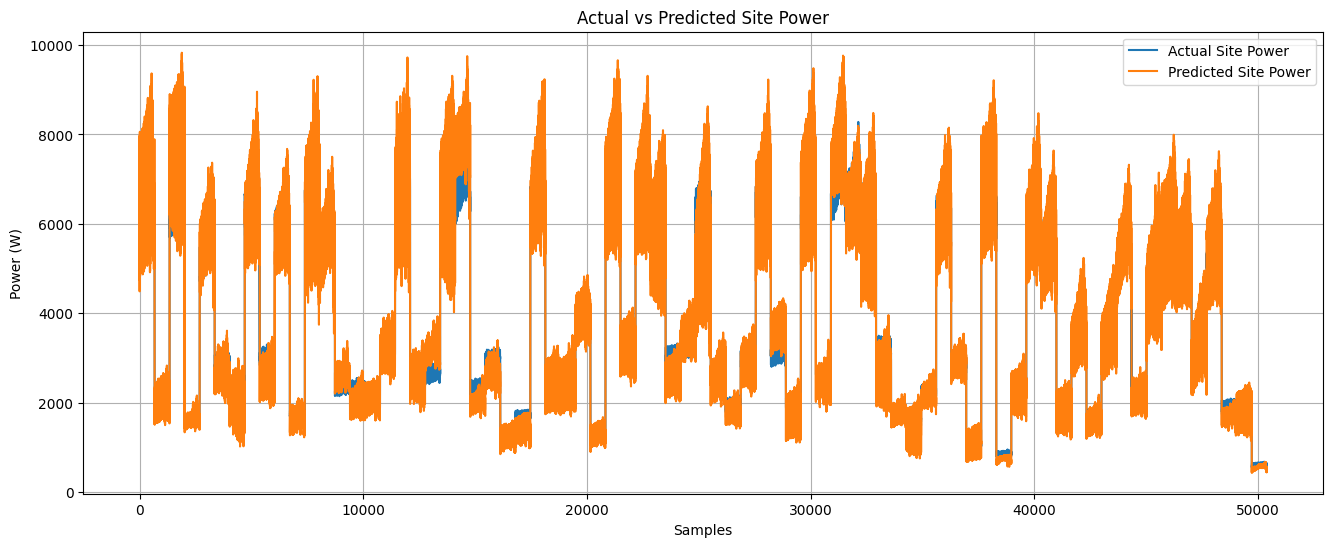

In [110]:
# ============================================================
# ACTUAL VS PREDICTED POWER GRAPH
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    final_df['site_power'].values,
    label='Actual Site Power'
)

plt.plot(
    final_df['predicted_site_power'].values,
    label='Predicted Site Power'
)

plt.xlabel('Samples')
plt.ylabel('Power (W)')
plt.title('Actual vs Predicted Site Power')
plt.legend()
plt.grid(True)

plt.show()

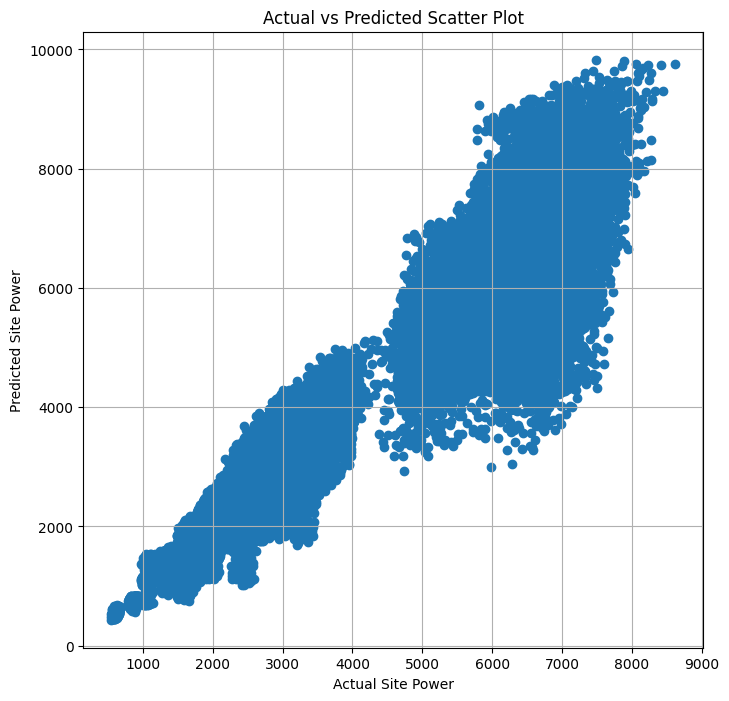

In [111]:
# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    final_df['site_power'],
    final_df['predicted_site_power']
)

plt.xlabel('Actual Site Power')
plt.ylabel('Predicted Site Power')
plt.title('Actual vs Predicted Scatter Plot')
plt.grid(True)
plt.show()

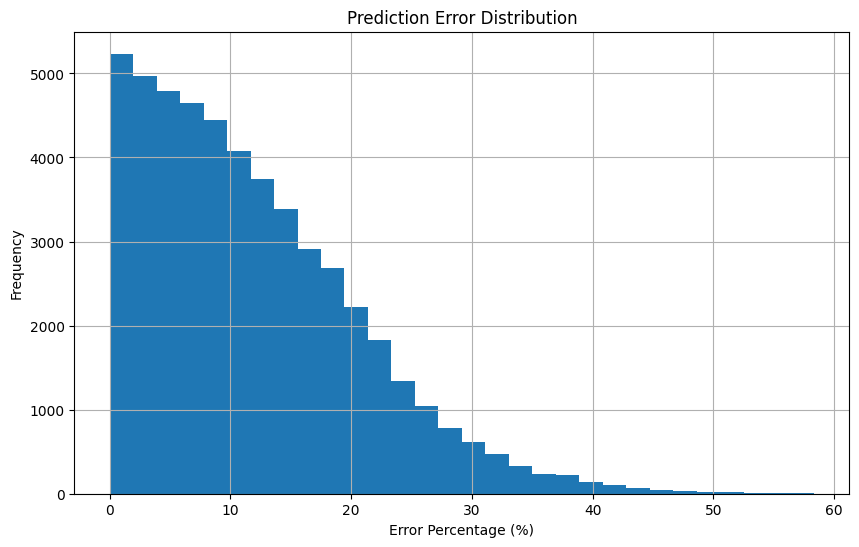

In [112]:
# ============================================================
# ERROR PERCENTAGE HISTOGRAM
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    final_df['error_percentage'],
    bins=30
)

plt.xlabel('Error Percentage (%)')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.grid(True)
plt.show()